# [LAB 09] 2-2. 가정 검정 모듈화
## #연습문제

In [15]:
from hossam import load_data
from helpers import *

In [16]:
origin = load_data('father-son')
origin.head()

📚 아버지와 아들의 키를 조사한 데이터 (출처: https://www.kaggle.com/datasets/aungdev/pearson-dataset-heights-of-fathers-and-their-sons)


,fheight,sheight
0,65.049,59.778
1,63.251,63.214
2,64.955,63.342
3,65.752,62.792
4,61.137,64.281


In [17]:
fit = my_ols.fit_model(origin, y='sheight')
fit

#### 문제 1. 잔차(resid)와 적합값(y_pred)을 추출하라

In [18]:
ols_df = origin.copy()
ols_df['y_pred'] = fit.fittedvalues
ols_df['resid'] = fit.resid
ols_df.head()

,fheight,sheight,y_pred,resid
0,65.049,59.778,67.328,-7.549
1,63.251,63.214,66.403,-3.189
2,64.955,63.342,67.280,-3.937
3,65.752,62.792,67.690,-4.897
4,61.137,64.281,65.317,-1.036


#### 문제 2. 선형성과 등분산성 확인

,statistic,p-value,linearity,result
Ramsey RESET,0.032,0.859,True,귀무가설 채택 → 선형성 위배 근거 없음


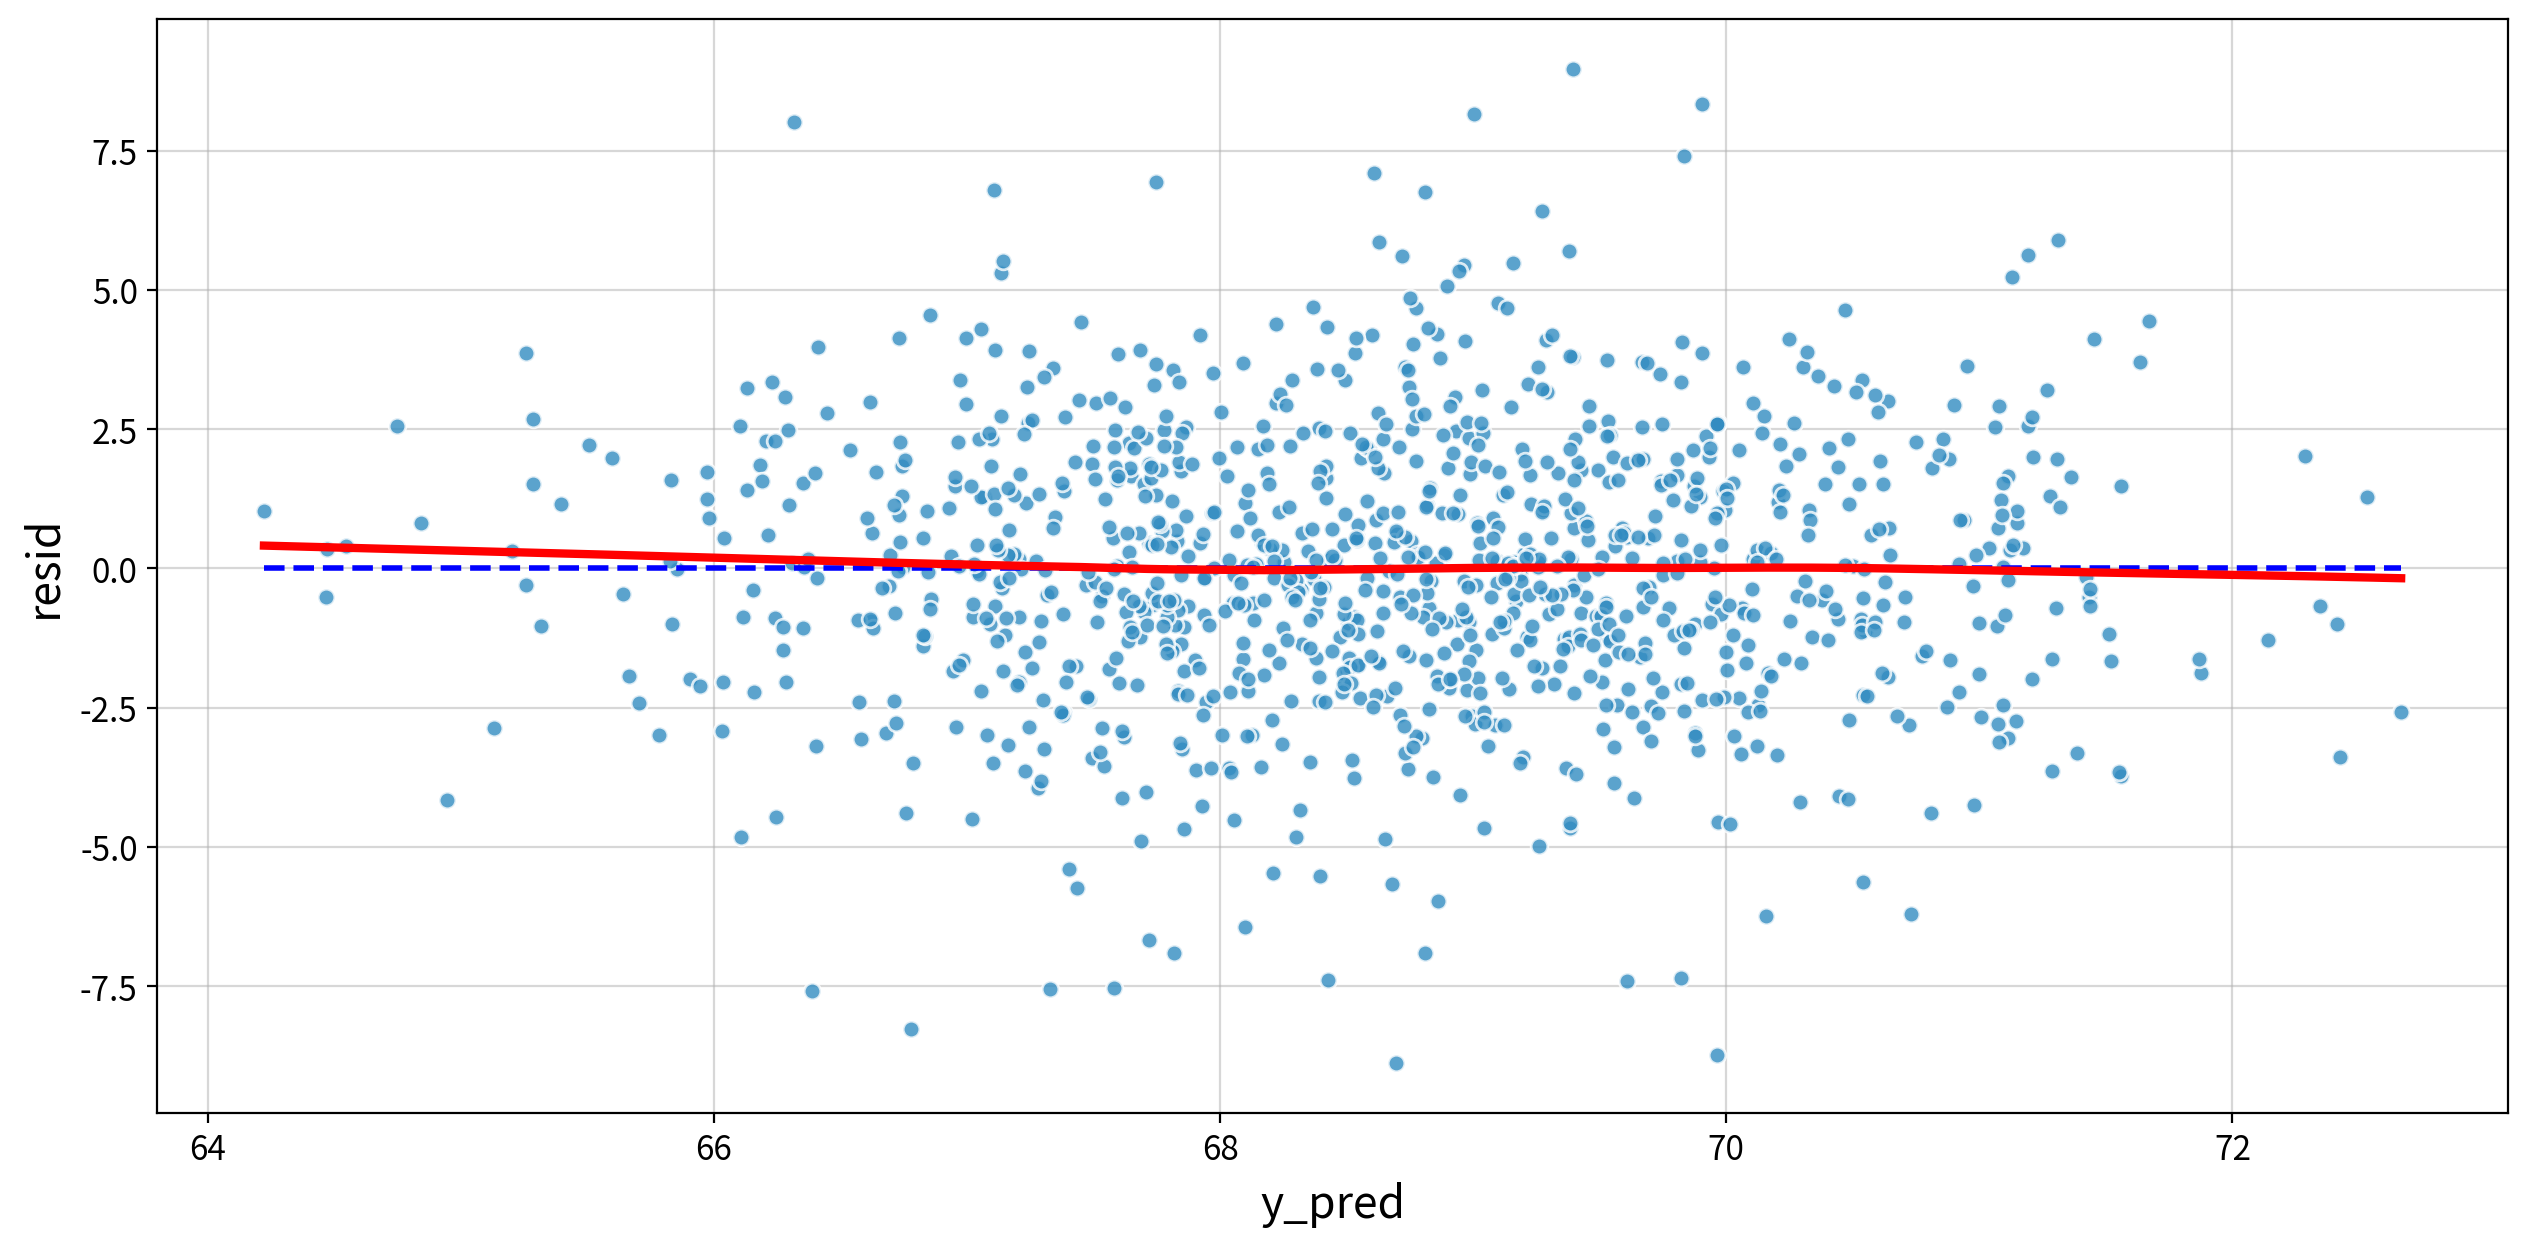

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,0.003,0.960,0.003,0.960,True,귀무가설 채택 → 등분산성 만족


In [19]:
my_ols.test_linear(fit)
my_ols.test_equalvar(fit)

- 잔차-적합값 산점도를 확인해보니, 잔차가 0을 중심으로 무작위하게 분포하고 뚜렷한 곡선 패턴이 보이지 않는다. 뚜렷하게 곡선의 형태를 보이지 않았기 때문에 선형성 가정은 대체로 만족한다고 판단하였다. 또한 Ramsey RESET 검정의 p-value가 0.05 이상이면 선형성을 위배하였다는 근거가 있다고 볼 수 없다.
- Breusch-Pagan 검정 결과 F p-value가 0.05 이상으로 귀무가설을 채택하여 등분산성 가정을 만족한다고 판단한다.

#### 문제 3. 정규성

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.022,0.667,True,귀무가설 채택 → 정규성 만족


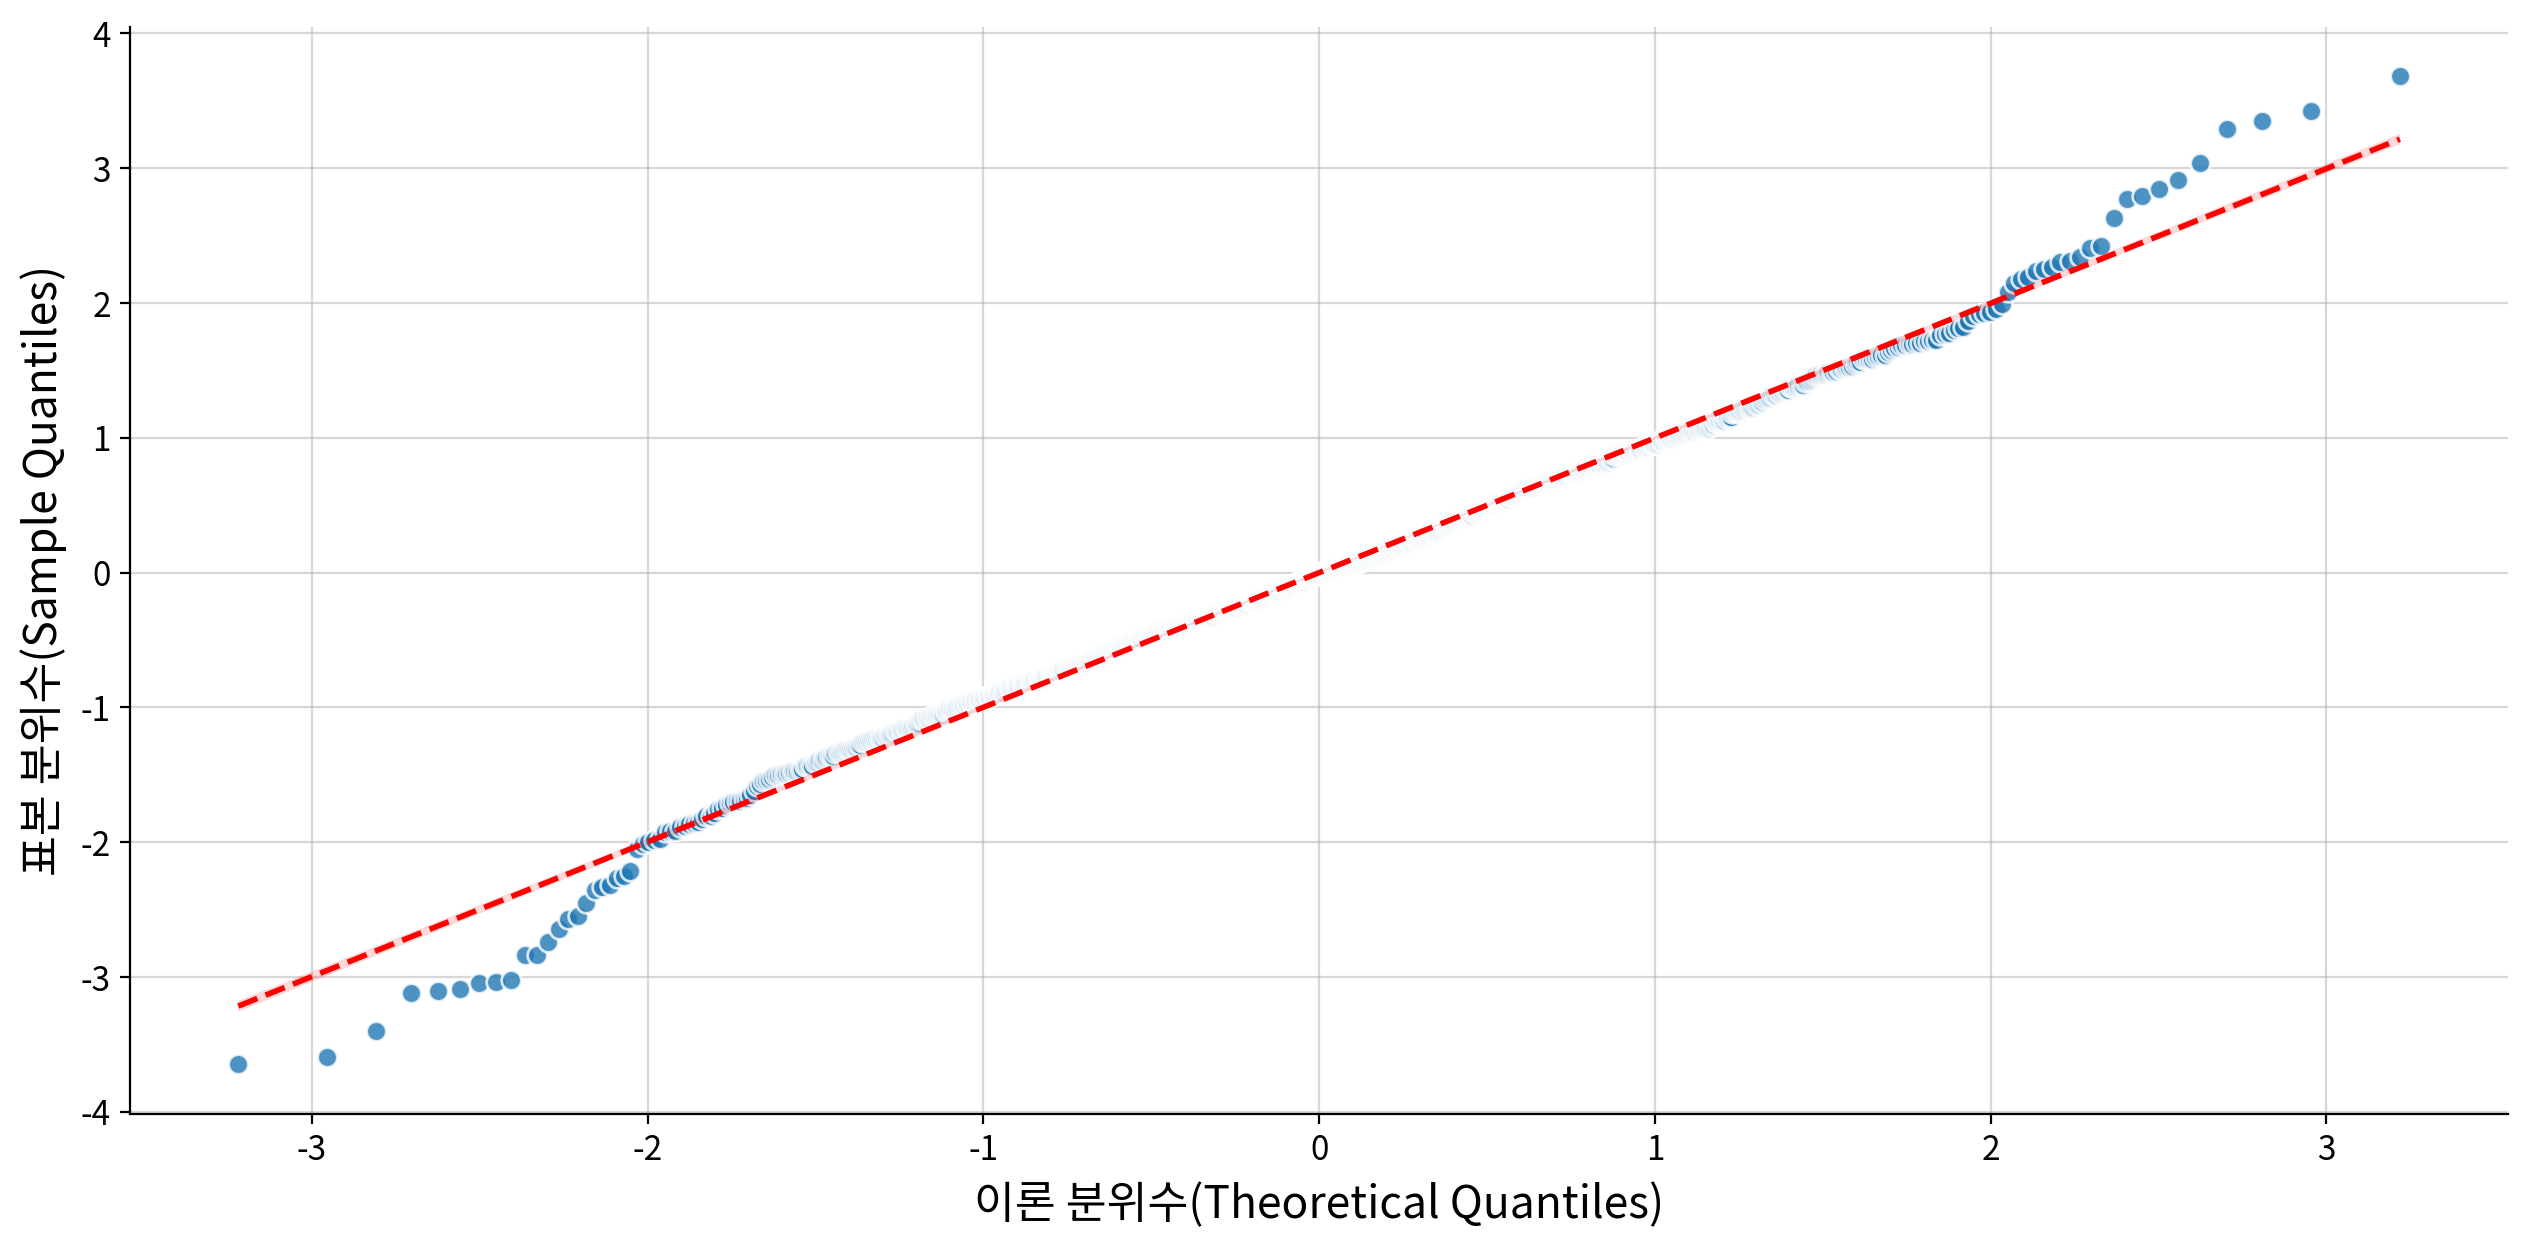

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,65~71,71.430,위배
±2√MSE,95.000,94~96,95.730,충족
±3√MSE,99.700,99~100,98.700,위배


√MSE = 2.44 / 구간 규칙 판정: 정규성 위배


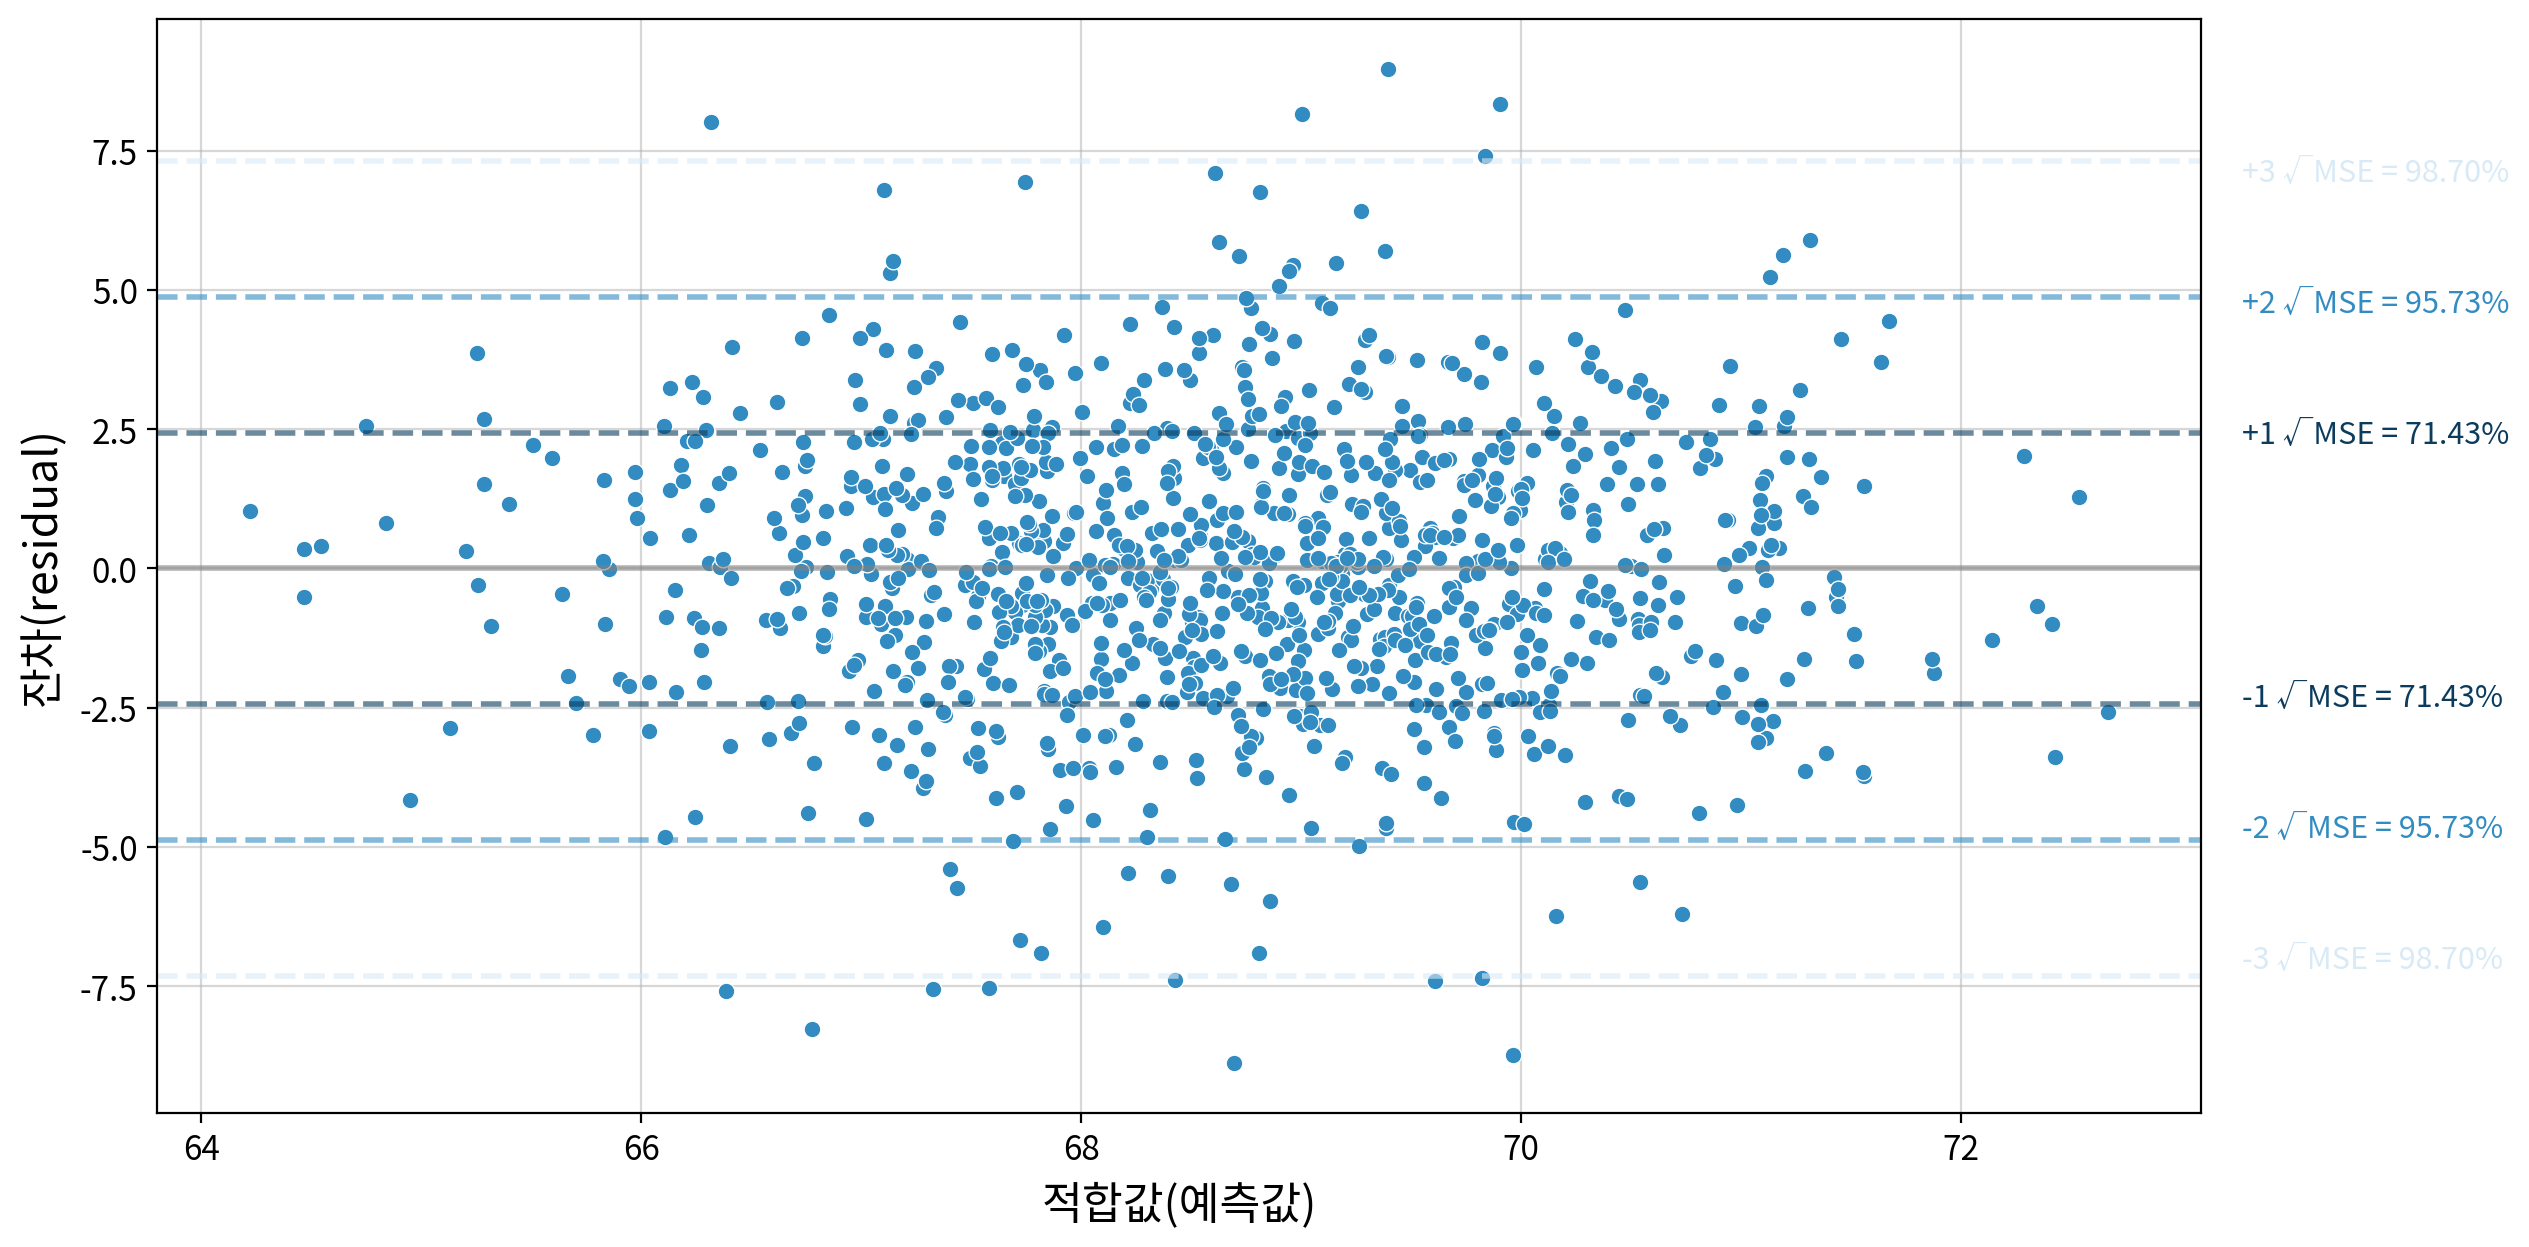

In [20]:
my_ols.test_normal(fit)

In [21]:
from scipy.stats import shapiro
from pandas import DataFrame

method = "Shapiro-Wilk"
s, p = shapiro(fit.resid)

DataFrame([{
    'statistic': round(s, 4),
    'p-value': round(p, 4),
    'normality': p >= 0.05,
    "result":"귀무가설 채택 → 정규성 만족" if p >= 0.05 else "대립가설 채택 → 정규성 위배"
}], index=[method])

,statistic,p-value,normality,result
Shapiro-Wilk,0.993,0.000,False,대립가설 채택 → 정규성 위배


- Q-Q plot을 확인한 결과, 잔차의 중앙 부분은 기준선에 대체로 일치하고 양쪽 꼬리 부분에서 잔차들이 기준선에서 벗어남을 보인다.
- Shapiro-Wilk 검정에서는 p-value <0.001로 0.05보다 작아 귀무가설을 기각하고 정규성을 만족하지 못한다고 판단한다.
- KS 검정에서는 p-value=0.667 > 0.05로 정규성 위반 근거가 없다.
- ±√MSE 구간 규칙에서도 ±1√MSE와 ±3√MSE 구간이 기대 비율에서 벗어나 정규성을 충족하지 못했다.

#### 문제 4. 독립성과 종합판정

In [22]:
my_ols.test_independent(fit)

,statistic,independence,result
Durbin-Watso,0.766,False,독립성 위반 (양(+)의 자기상관)


- Durbin-Watson 통계량이 1.5보다 작으므로 양의 자기상관 가능성이 있다. 따라서 독립성 가정이 위배될 수 있다.

#### 4대 가정 종합결론
- 회귀식 sheight = 0.51 * fheight + 33.89(R2 = 0.251, n=1078)


|가정|검정(도구)|수치|판정|
|-|-|-|-|
|선형성|Ramsey RESET|0.859|만족|
|정규성|K-S(권장) /Shapiro(참고)|KS p = 0.667|만족|
|등분산성|Breusch-Pagan|0.960|만족|
|독립성|Durbin-Watso|DW=0.766|위반|

- 네 가지 가정의 진단결과 해당 회귀모형은 대체로 신뢰 가능하다. 
- 잔차-적합값 산점도에서 뚜렷한 곡선 패턴이 보이지 않았고 Ramsey RESET 검정의 p-value가 0.859로 0.05보다 커 선형성 위배 근거가 없었다.
- KS 검정에서도 p-value가 0.667로 0.05보다 크게 나타나 정규정을 만족하였다. 물론 Shapiro-Wilk 검정의 p-value가 0.001보다 작아 정규성 가정은 완전히 만족하지 못한다고 유의해야 하나 n=1078이므로 중심극한정리(CLT)로 계수 추론에는 큰 문제가 없다. 
- Breusch-Pagan 검정에서도 F p-value가 0.960으로 등분산성 가정을 만족하였다. 
- 독립성이 0.766으로 1.5보다 작아 양의 자기상관이 존재할 가능성이 있으나 이 회귀모형은 시계열 데이터가 아니므로 해당 검정은 크게 신경쓰지 않아도 될 것이라고 생각된다. 따라서 본 회귀모형은 신뢰 가능한 모형이라고 판단된다.